In [1]:
import easyocr
import pydicom
import pathlib
import tempfile
from PIL import Image
from pathlib import Path
from presidio_image_redactor import DicomImageRedactorEngine, ImageAnalyzerEngine, ContrastSegmentedImageEnhancer
import pytesseract
from typing import Tuple

class DicomEngine(DicomImageRedactorEngine): 
    def __init__(self):
        super().__init__()
        self.image_analyzer_engine = ImageAnalyzerEngine(image_preprocessor=ContrastSegmentedImageEnhancer())
        self.ocr_kwargs = {"lang": r"eng", "config": r'--psm 11 --oem 1'}
        self.padding_width = 25
        
    def _easyocr(self, file_path:str) -> None:
        reader = easyocr.Reader(['en'])
        result = reader.readtext(file_path)
        print(result)
        formatted_result = self._easy_result_format(result)
        return formatted_result
    
    def _easy_result_format(self,easy_result:list) -> list: 
        left = []
        top = []
        width = []
        height = []
        text = []
        conf_score = []
        for entry in easy_result:
            bounding_boxes = entry[0]
            text.append(entry[1])
            conf_score.append(entry[2])
            x_max = bounding_boxes[0][0]
            x_min = bounding_boxes[0][0]
            y_max = bounding_boxes[0][1]
            y_min = bounding_boxes[0][1]
            for i, coord_set in enumerate(bounding_boxes):
                if i % 2 == 0:
                    if coord_set[0] > x_max:
                        x_max = coord_set[0]
                        width.append(x_max)
                    elif coord_set[0] <= x_min:
                        x_min = coord_set[0]
                        left.append(x_min)
                else: 
                    if coord_set[1] > y_max:
                        y_max = coord_set[1]
                        top.append(y_max)
                    elif coord_set[1] <= y_min:
                        y_min = coord_set[1]
                        height.append(y_min)
            
        formatted_output = {
            "left": left,
            "top": top,
            "width": width,
            "height": height,
            "test": text,
            "conf": conf_score,
        }
        return formatted_output


    def get_ocr_from_dicom(self, dicom_file_path: pathlib.PosixPath) -> Tuple[list,dict]:
        """
        :param dicom_file_path: Path to a DICOM file
        :return: The OCR text from the DICOM file
        """
        # Load image for processing
        with tempfile.TemporaryDirectory() as tmpdirname:
            # Convert DICOM to PNG and add padding for OCR (during analysis)
            _, is_greyscale = self._convert_dcm_to_png(
                dicom_file_path, output_dir=tmpdirname
            )
            png_filepath = f"{tmpdirname}/{dicom_file_path.stem}.png"
            loaded_image = Image.open(png_filepath)
            image = self._add_padding(
                loaded_image, is_greyscale, self.padding_width
            )
            easy_ocr_results = self._easyocr(png_filepath)
        
        # Run OCR on image
        tess_ocr_results = self.image_analyzer_engine.ocr.perform_ocr(image, **self.ocr_kwargs)
        return tess_ocr_results, easy_ocr_results
    

/home/maxthorpe/.pyenv/versions/3.9.13/envs/image_redactor/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define & Run 
MyClass = DicomEngine()
tess_result, easy_result = MyClass.get_ocr_from_dicom(Path("test_images/davidson.dcm"))
print(tess_result, easy_result, sep="\n")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


KeyboardInterrupt: 

In [56]:
MyClass._convert_dcm_to_png(Path("test_images/davidson.dcm"), output_dir="test_images")

((1760, 2140), True)

In [57]:
print(easy_result)

{'left': [0, 10, 1743, 1888], 'top': [52, 92, 77, 150], 'width': [824, 370, 2103, 2126], 'height': [0, 38, 11, 94], 'conf': [0.6466452093278293, 0.5815492520635394, 0.9742921560686912, 0.9998113225309943]}


In [58]:
# Draw bounding boxes
from PIL import Image, ImageDraw

def draw_bounding_boxes(image_path, coordinates):
    """
    Draws bounding boxes on the image based on the coordinates provided.
    
    :param image_path: Path to the input PNG image.
    :param coordinates: A dictionary with 'left', 'top', 'width', and 'height' as keys.
    """
    # Load the image
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)

    # Extract coordinates
    lefts, tops, widths, heights = coordinates['left'], coordinates['top'], coordinates['width'], coordinates['height']

    # Draw each bounding box
    for left, top, width, height in zip(lefts, tops, widths, heights):
        right, bottom = width, height
        draw.rectangle([left, bottom, right, top], outline="red")

    # Save or display the image
    image.show()  # To display the image
    # image.save('output_image.png')  # To save the image to a file



0
10
1743
1888


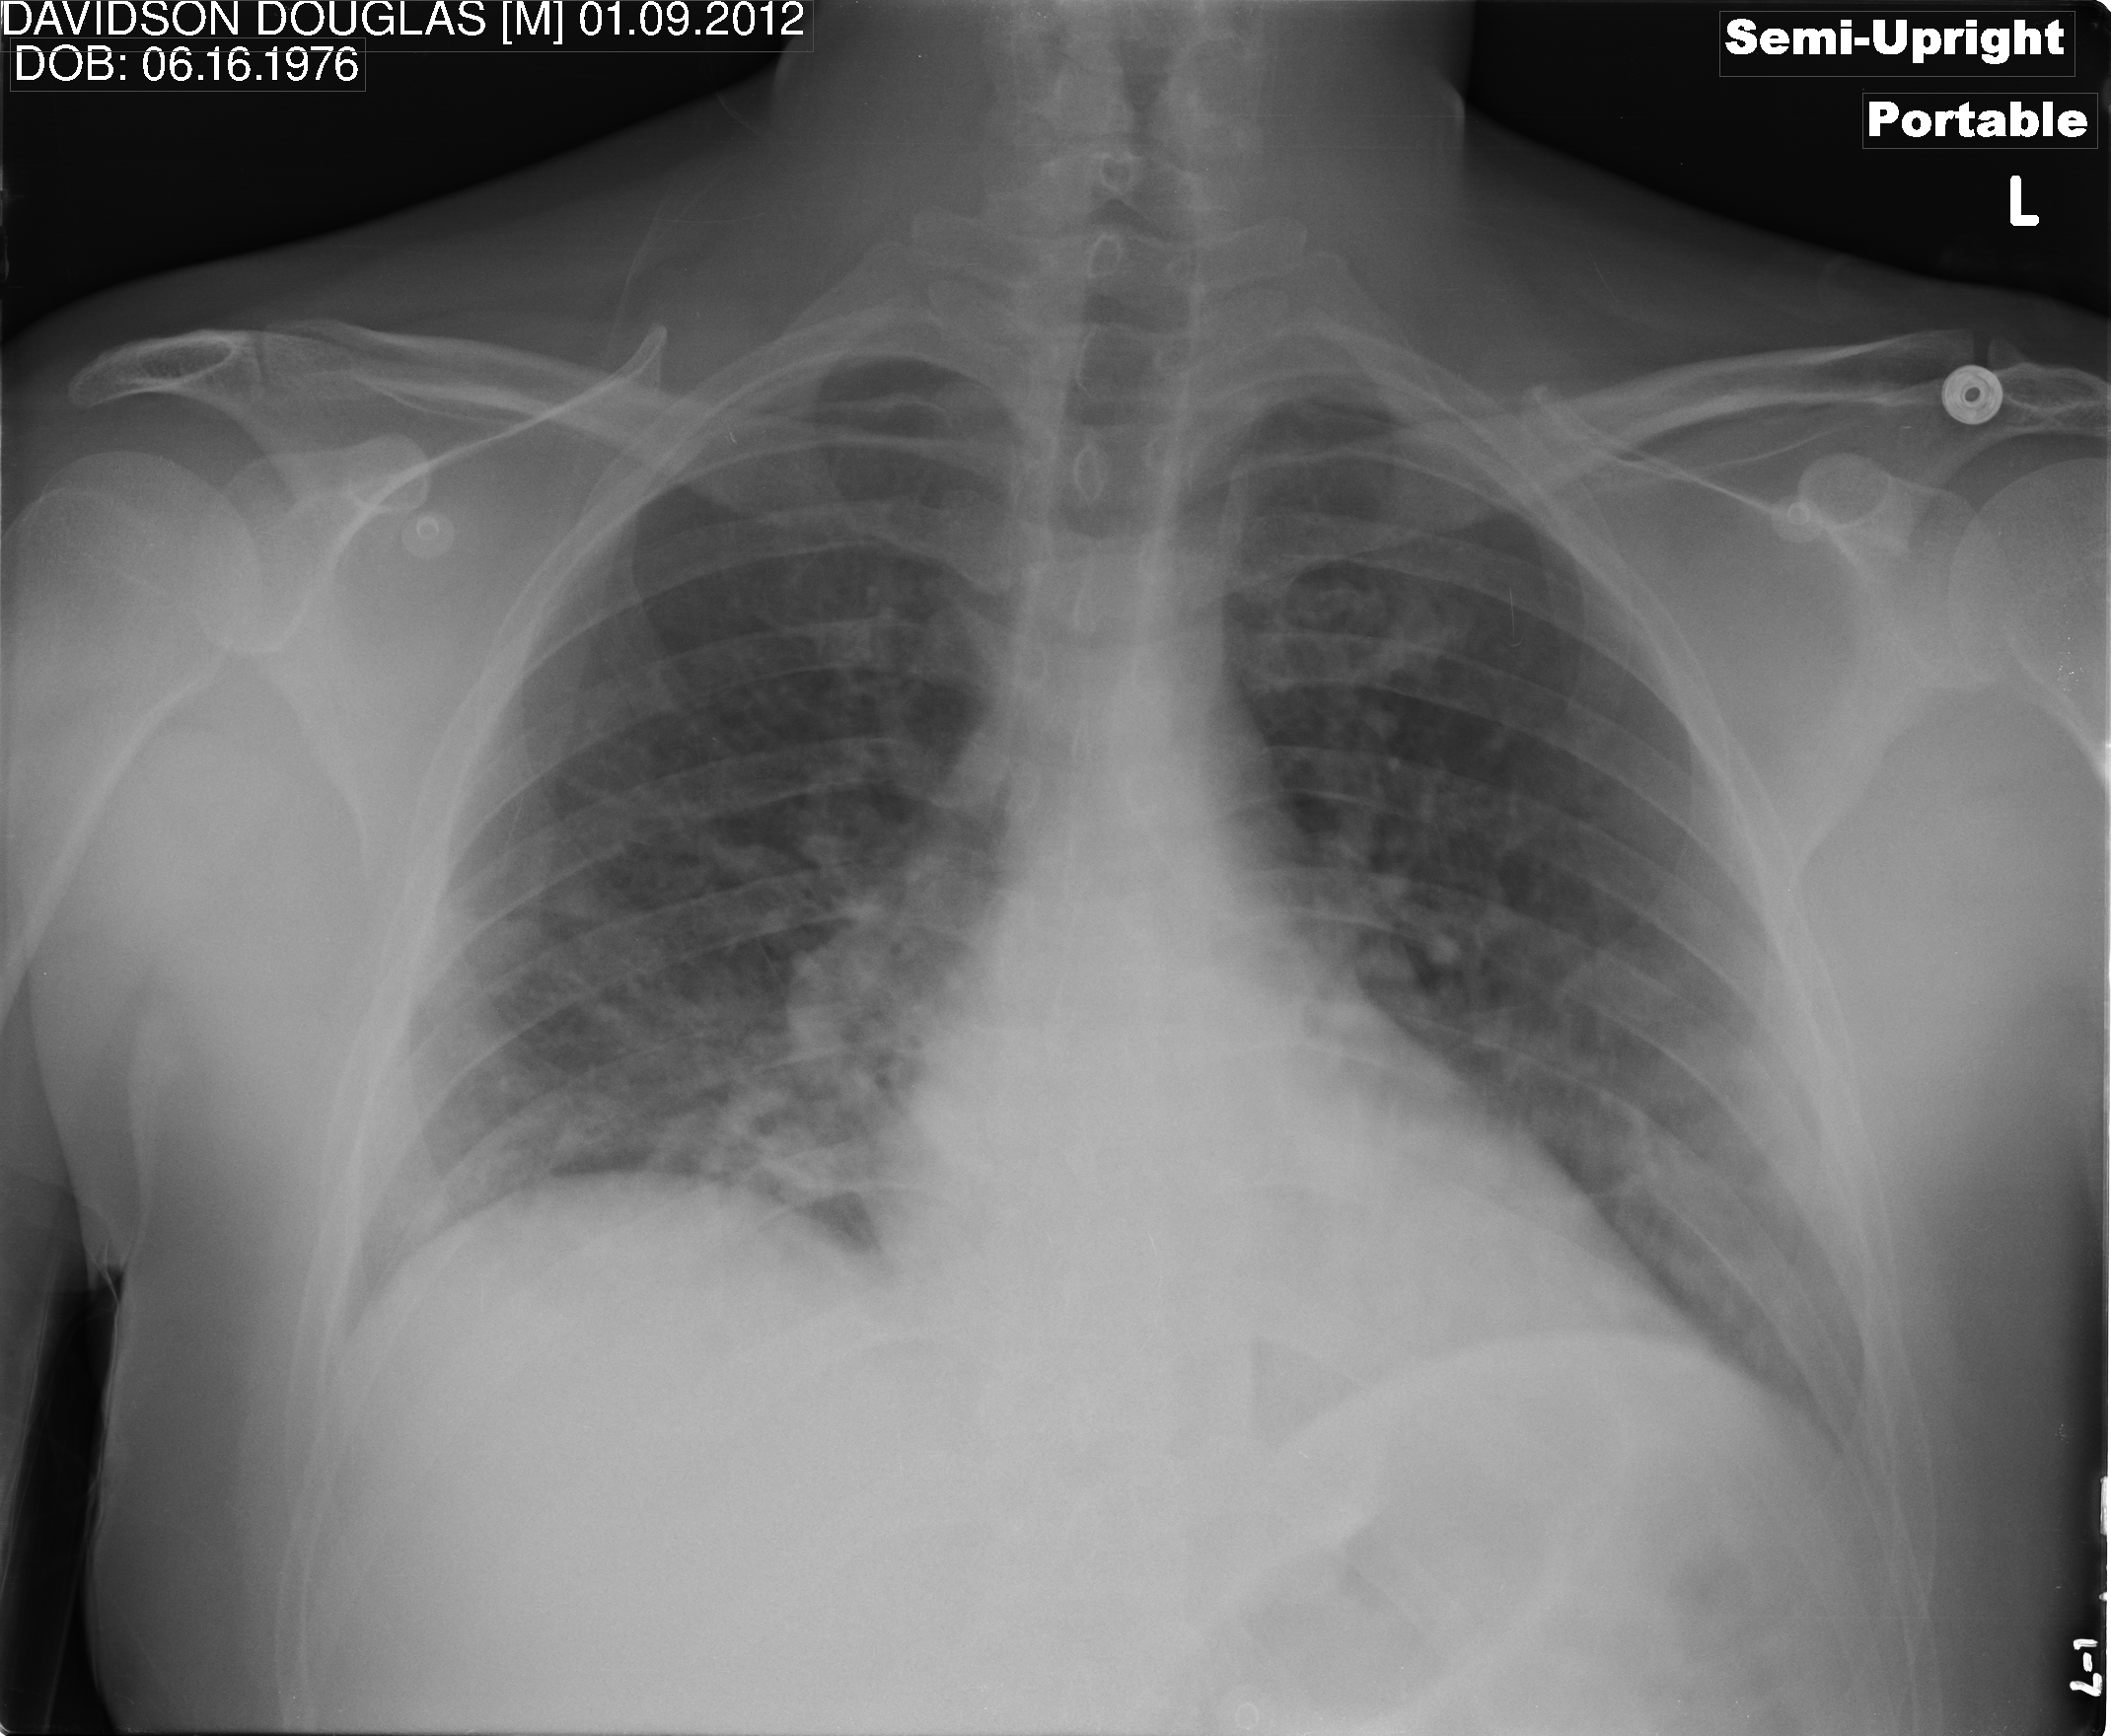

In [59]:

# Path to your PNG image
image_path = 'test_images/davidson.png'

# Call the function
draw_bounding_boxes(image_path, easy_result)

In [9]:
import easyocr
reader = easyocr.Reader(['en'])
result = reader.readtext('test_images/davidson.png')
print(result)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


[([[0, 0], [824, 0], [824, 52], [0, 52]], 'DAVIDSON DOUGLAS [M] 01.09.2012', 0.6466452093278293), ([[10, 38], [370, 38], [370, 92], [10, 92]], 'DOB: 06.16.1976', 0.5815492520635394), ([[1743, 11], [2103, 11], [2103, 77], [1743, 77]], 'Semi-Upright', 0.9742921560686912), ([[1888, 94], [2126, 94], [2126, 150], [1888, 150]], 'Portable', 0.9998113225309943)]


In [ ]:
# testing w/ nlp engine 
from presidio_analyzer import AnalyzerEngine
from presidio_analyzer.nlp_engine import NlpEngineProvider, TransformersNlpEngine
from fw_presidio_image_redactor.utils.pretrained_transformer import get_pretrained_transformer_model
import torch.nn.functional as F


get_pretrained_transformer_model()

# Define constants
TRANSFORMERS_CONFIG_FILE = (
    # "/home/maxthorpe/Git/presidio-image-redactor/fw_presidio_image_redactor/nlp_configs/transformers.yaml"
    "/flywheel/v0/fw_presidio_image_redactor/nlp_configs/transformers.yaml"
)
TEXT = ""
TEXT_LIST = [item for item in easy_result['test']]
TEXT = ", ".join(TEXT_LIST)
TEXT = TEXT.lower()
print(TEXT)
# Set pre-trained model as NLP engine
provider = NlpEngineProvider(conf_file=TRANSFORMERS_CONFIG_FILE)
nlp_engine = provider.create_engine()

print(nlp_engine)
MyAnalyzerEngine = AnalyzerEngine(nlp_engine=nlp_engine, supported_languages=["en"])
nlp_artifacts = MyAnalyzerEngine.nlp_engine.process_text(TEXT.lower(), "en")
print(nlp_artifacts.entities)
print(nlp_artifacts.scores)
print(nlp_artifacts)